Imports and hardware test

In [17]:
import fiftyone as fo
import fiftyone.zoo as foz
from ultralytics import YOLO
import torch
import os

#hardware test
print(f"GPU is ready: {torch.cuda.is_available()}")

GPU is ready: True


Data acquisition and preperation

In [18]:
dataset_path = os.path.abspath("../../datasets/Person&Head_DataSet")
print(f"Dataset path: {dataset_path}")

Dataset path: c:\Users\Dawid\Desktop\praca inżynierska\real-time-alaysis-research\datasets\Person&Head_DataSet


Global configuration

In [ ]:
#samples variables
NUMBER_OF_SAMPLES = 2000
RATIO_OF_TRAIN_SAMPLES = 0.8
NUMBER_OF_TRAIN_SAMPLES = int(NUMBER_OF_SAMPLES * RATIO_OF_TRAIN_SAMPLES)

#train variables
EPOCHS = 100
BATCH = 0.8
WORKERS = 4
IMG_SIZE = 640
PATIENCE = 15

MODEL_TYPE = 'yolov8n.pt'
VERSION = 2
MODEL_NAME = f"{MODEL_TYPE.split('.')[0]}_V{VERSION}_S{NUMBER_OF_SAMPLES}_E{EPOCHS}"

Load dataset form Open Imagines V7 and export them to YOLO format

In [20]:
dataset = foz.load_zoo_dataset(
    "open-images-v7",
    split="validation",
    label_types=["detections"],
    classes=["Person", "Human head"],
    max_samples=NUMBER_OF_SAMPLES,
    seed=42,
    shuffle=True
)

Necessary images already downloaded
Existing download of split 'validation' is sufficient
Loading existing dataset 'open-images-v7-validation-5000'. To reload from disk, either delete the existing dataset or provide a custom `dataset_name` to use


Taging data set and exporitng to YOLO format

In [21]:

# clear old tags if re-running this cell
dataset.untag_samples(dataset.distinct("tags"))

# automatically split the dataset into Train (80%) and Val (20%)
train_view = dataset.take(NUMBER_OF_TRAIN_SAMPLES, seed=42)
train_view.tag_samples("train")

# select the remaining samples for validation
val_view = dataset.exclude(train_view)
val_view.tag_samples("val")

# export to YOLOv format with split handling
# iterate through the tags to create the correct subfolder structure
for split in ["train", "val"]:
    split_view = dataset.match_tags(split)
    split_view.export(
        export_dir=dataset_path,
        dataset_type=fo.types.YOLOv5Dataset,
        label_types=["detections"],
        classes=["Person", "Human head"],
        split=split # key: it creates 'train' and 'val' keys in dataset.yaml
    )

Directory 'c:\Users\Dawid\Desktop\praca inżynierska\real-time-alaysis-research\datasets\Person&Head_DataSet' already exists; export will be merged with existing files
Ignoring unsupported parameter 'label_types'
   1% |/--------------|   21/4000 [109.2ms elapsed, 20.7s remaining, 192.3 samples/s] 

c:\Users\Dawid\AppData\Local\Programs\Python\Python311\Lib\site-packages\fiftyone\utils\yolo.py:1154: UserWarning: Ignoring object with label 'Human face' not in provided classes
  warnings.warn(msg)
c:\Users\Dawid\AppData\Local\Programs\Python\Python311\Lib\site-packages\fiftyone\utils\yolo.py:1154: UserWarning: Ignoring object with label 'Human hair' not in provided classes
  warnings.warn(msg)
c:\Users\Dawid\AppData\Local\Programs\Python\Python311\Lib\site-packages\fiftyone\utils\yolo.py:1154: UserWarning: Ignoring object with label 'Glasses' not in provided classes
  warnings.warn(msg)
c:\Users\Dawid\AppData\Local\Programs\Python\Python311\Lib\site-packages\fiftyone\utils\yolo.py:1154: UserWarning: Ignoring object with label 'Girl' not in provided classes
  warnings.warn(msg)
c:\Users\Dawid\AppData\Local\Programs\Python\Python311\Lib\site-packages\fiftyone\utils\yolo.py:1154: UserWarning: Ignoring object with label 'Sunglasses' not in provided classes
  warnings.warn(msg)
c:\Users\

c:\Users\Dawid\AppData\Local\Programs\Python\Python311\Lib\site-packages\fiftyone\utils\yolo.py:1154: UserWarning: Ignoring object with label 'Vegetable' not in provided classes
  warnings.warn(msg)
c:\Users\Dawid\AppData\Local\Programs\Python\Python311\Lib\site-packages\fiftyone\utils\yolo.py:1154: UserWarning: Ignoring object with label 'Musical instrument' not in provided classes
  warnings.warn(msg)
c:\Users\Dawid\AppData\Local\Programs\Python\Python311\Lib\site-packages\fiftyone\utils\yolo.py:1154: UserWarning: Ignoring object with label 'Doll' not in provided classes
  warnings.warn(msg)
c:\Users\Dawid\AppData\Local\Programs\Python\Python311\Lib\site-packages\fiftyone\utils\yolo.py:1154: UserWarning: Ignoring object with label 'Sword' not in provided classes
  warnings.warn(msg)
c:\Users\Dawid\AppData\Local\Programs\Python\Python311\Lib\site-packages\fiftyone\utils\yolo.py:1154: UserWarning: Ignoring object with label 'Weapon' not in provided classes
  warnings.warn(msg)
c:\Users

   2% ||--------------|   97/4000 [415.5ms elapsed, 16.7s remaining, 233.5 samples/s] 

c:\Users\Dawid\AppData\Local\Programs\Python\Python311\Lib\site-packages\fiftyone\utils\yolo.py:1154: UserWarning: Ignoring object with label 'Suit' not in provided classes
  warnings.warn(msg)
c:\Users\Dawid\AppData\Local\Programs\Python\Python311\Lib\site-packages\fiftyone\utils\yolo.py:1154: UserWarning: Ignoring object with label 'Volleyball (Ball)' not in provided classes
  warnings.warn(msg)
c:\Users\Dawid\AppData\Local\Programs\Python\Python311\Lib\site-packages\fiftyone\utils\yolo.py:1154: UserWarning: Ignoring object with label 'Sports uniform' not in provided classes
  warnings.warn(msg)


...

  19% |██/------------|  754/4000 [3.8s elapsed, 15.8s remaining, 228.3 samples/s]    

c:\Users\Dawid\AppData\Local\Programs\Python\Python311\Lib\site-packages\fiftyone\utils\yolo.py:1154: UserWarning: Ignoring object with label 'Personal flotation device' not in provided classes
  warnings.warn(msg)
c:\Users\Dawid\AppData\Local\Programs\Python\Python311\Lib\site-packages\fiftyone\utils\yolo.py:1154: UserWarning: Ignoring object with label 'Treadmill' not in provided classes
  warnings.warn(msg)
c:\Users\Dawid\AppData\Local\Programs\Python\Python311\Lib\site-packages\fiftyone\utils\yolo.py:1154: UserWarning: Ignoring object with label 'Kitchen & dining room table' not in provided classes
  warnings.warn(msg)
c:\Users\Dawid\AppData\Local\Programs\Python\Python311\Lib\site-packages\fiftyone\utils\yolo.py:1154: UserWarning: Ignoring object with label 'Countertop' not in provided classes
  warnings.warn(msg)
c:\Users\Dawid\AppData\Local\Programs\Python\Python311\Lib\site-packages\fiftyone\utils\yolo.py:1154: UserWarning: Ignoring object with label 'Coat' not in provided clas

  20% |██\------------|  783/4000 [3.9s elapsed, 15.8s remaining, 219.9 samples/s]    


c:\Users\Dawid\AppData\Local\Programs\Python\Python311\Lib\site-packages\fiftyone\utils\yolo.py:1154: UserWarning: Ignoring object with label 'Candy' not in provided classes
  warnings.warn(msg)


KeyboardInterrupt: 

Model training

In [ ]:
#initialize model
model = YOLO(MODEL_TYPE)

#dataset config path
yaml_file_path = os.path.abspath("../../datasets/Person&Head_DataSet/dataset.yaml")

#start training porcess
results = model.train(
    data=yaml_file_path,
    epochs=EPOCHS,             # Number of training epochs
    imgsz=IMG_SIZE,            # Input image resolution
    batch=BATCH,             # Adjust this based on VRAM
    device=0,             # Target GPU
    half=True,            # Use FP16 precision for faster training on Blackwell
    workers=WORKERS,            # Number of CPU workers for data loading
    name=MODEL_NAME, # Result folder name inside 'runs/detect/'
    patience=PATIENCE,
    exist_ok=True         # Overwrite existing folder with the same name
)

print("Training session finished!")

Ultralytics 8.4.21  Python-3.11.9 torch-2.10.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=0.8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\Dawid\Desktop\praca inynierska\real-time-alaysis-research\datasets\Person&Head_DataSet\dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=True, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_V2_S5000_E100,

Evaluation and Performance Metrics

Looking for results in: c:\Users\Dawid\Desktop\praca inżynierska\real-time-alaysis-research\scripts\YOLO\runs\detect\yolov8n_V2_S5000_E100
CSV log path: c:\Users\Dawid\Desktop\praca inżynierska\real-time-alaysis-research\scripts\YOLO\runs\detect\yolov8n_V2_S5000_E100\results.csv
PNG plot path: c:\Users\Dawid\Desktop\praca inżynierska\real-time-alaysis-research\scripts\YOLO\runs\detect\yolov8n_V2_S5000_E100\results.png


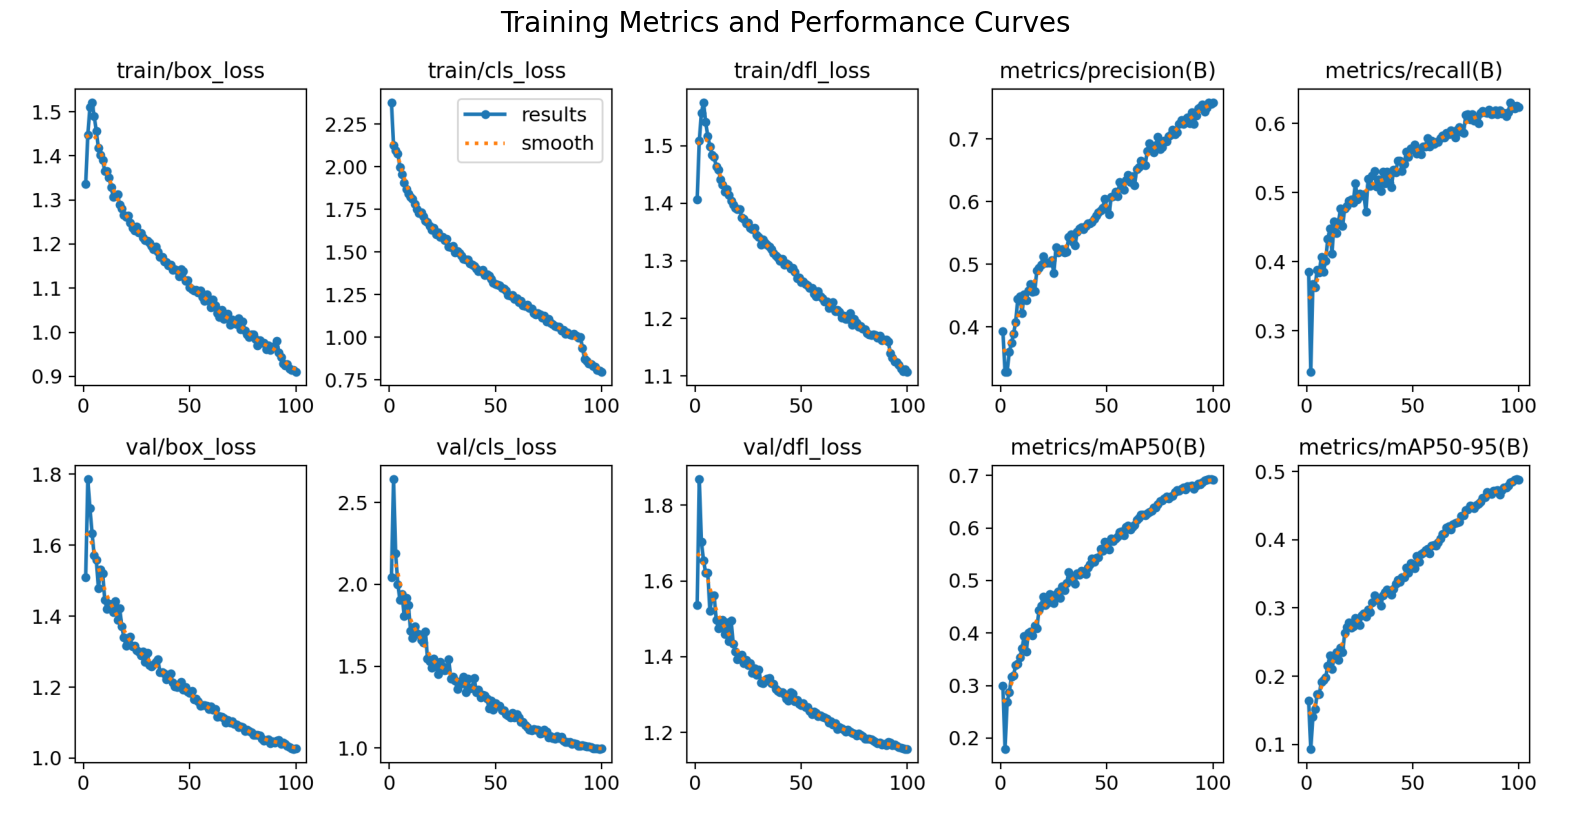

------------------------------
FINAL TRAINING SUMMARY:
Epochs completed: 100
Final Box Loss:  0.9098
Final Class Loss: 0.7953
mAP50:           0.6922
mAP50-95:        0.4880
------------------------------


In [ ]:
import matplotlib.pyplot as plt
import cv2

results_dir = os.path.abspath(f"../YOLO/runs/detect/{MODEL_NAME}")
results_csv = os.path.join(results_dir, "results.csv")
results_png = os.path.join(results_dir, "results.png")

print(f"Looking for results in: {results_dir}")
print(f"CSV log path: {results_csv}")
print(f"PNG plot path: {results_png}")

#display training curves (Loss, mAP, Precision, Recall)
if os.path.exists(results_png):
    img = cv2.imread(results_png)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(20, 12))
    plt.imshow(img)
    plt.title("Training Metrics and Performance Curves", fontsize=20)
    plt.axis('off')
    plt.show()
else:
    print("Optimization in progress or results.png not found yet.")

#print final summary from the CSV log
if os.path.exists(results_csv):
    import pandas as pd
    df = pd.read_csv(results_csv)
    
    # get the last row of the training log
    final_stats = df.iloc[-1]
    
    print("-" * 30)
    print("FINAL TRAINING SUMMARY:")
    print(f"Epochs completed: {len(df)}")
    print(f"Final Box Loss:  {final_stats.get('train/box_loss', 'N/A'):.4f}")
    print(f"Final Class Loss: {final_stats.get('train/cls_loss', 'N/A'):.4f}")
    print(f"mAP50:           {final_stats.get('metrics/mAP50(B)', 'N/A'):.4f}")
    print(f"mAP50-95:        {final_stats.get('metrics/mAP50-95(B)', 'N/A'):.4f}")
    print("-" * 30)

Benchmark

In [ ]:
import time
import numpy as np

# load the model
model_path = f"runs/detect/{MODEL_NAME}/weights/best.pt"
model = YOLO(model_path)

# Warm-up (Important for GPU)
# GPU needs a few runs to reach full clock speed
dummy_input = np.zeros((640, 640, 3), dtype=np.uint8)
for _ in range(10):
    _ = model.predict(dummy_input, verbose=False)

# benchmark loop
num_frames = 100
start_time = time.time()

for _ in range(num_frames):
    results = model.predict(dummy_input, verbose=False, device=0)

end_time = time.time()

# calculations
total_time = end_time - start_time
avg_time_ms = (total_time / num_frames) * 1000
fps = num_frames / total_time

print("-" * 30)
print(f"PERFORMANCE REPORT ({MODEL_TYPE})")
print(f"Average Inference Time: {avg_time_ms:.2f} ms")
print(f"Throughput:             {fps:.2f} FPS")
print(f"Device:                {torch.cuda.get_device_name(0)}")
print("-" * 30)

------------------------------
PERFORMANCE REPORT (yolov8n.pt)
Average Inference Time: 4.74 ms
Throughput:             210.96 FPS
Device:                NVIDIA GeForce RTX 5070 Ti
------------------------------
